In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.29MB/s]


In [4]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [5]:
class MLP(nn.Module):
    def __init__(self, hidden1, hidden2, activation):
        super().__init__()

        if activation == "relu":
            act = nn.ReLU()
        elif activation == "tanh":
            act = nn.Tanh()

        self.model = nn.Sequential(
            nn.Linear(28*28, hidden1),
            act,

            nn.Linear(hidden1, hidden2),
            act,

            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [6]:
def train_and_evaluate(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(correct / total)

    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss /= len(test_loader)
    test_accuracy = correct / total

    return train_losses, train_accuracies, test_loss, test_accuracy

In [7]:
experiments = {
    "Experiment 1": {
        "hidden1": 128,
        "hidden2": 64,
        "activation": "relu",
        "lr": 0.001
    },
    "Experiment 2": {
        "hidden1": 256,
        "hidden2": 128,
        "activation": "tanh",
        "lr": 0.0005
    }
}

In [8]:
results = {}

for name, params in experiments.items():
    print(f"\nRunning {name}")

    model = MLP(
        hidden1=params["hidden1"],
        hidden2=params["hidden2"],
        activation=params["activation"]
    )

    optimizer = optim.Adam(model.parameters(), lr=params["lr"])

    train_losses, train_accs, test_loss, test_acc = train_and_evaluate(
        model, optimizer
    )

    results[name] = {
        "train_losses": train_losses,
        "train_accuracies": train_accs,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    }

    print(f"Test Accuracy: {test_acc*100:.2f}%")


Running Experiment 1
Test Accuracy: 97.64%

Running Experiment 2
Test Accuracy: 97.29%


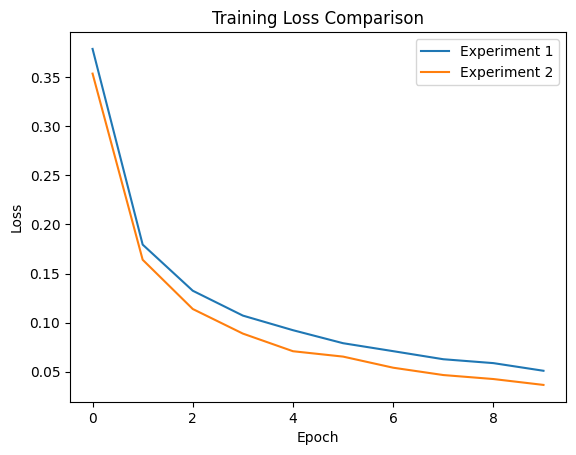

In [9]:
plt.figure()
for name in results:
    plt.plot(results[name]["train_losses"], label=name)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

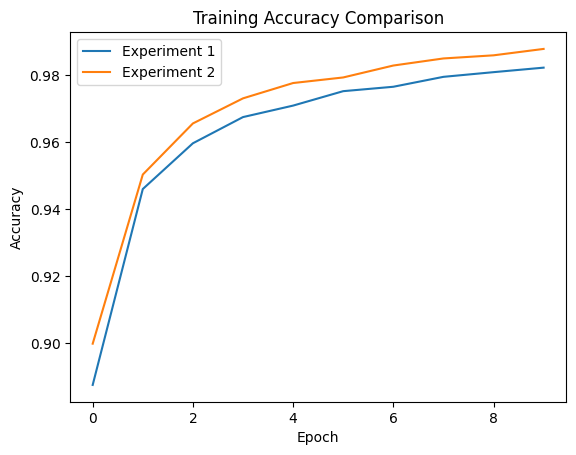

In [10]:
plt.figure()
for name in results:
    plt.plot(results[name]["train_accuracies"], label=name)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [11]:
for name in results:
    print(name)
    print(f"Final Test Loss: {results[name]['test_loss']:.4f}")
    print(f"Final Test Accuracy: {results[name]['test_accuracy']*100:.2f}%")
    print("-" * 40)

Experiment 1
Final Test Loss: 0.0774
Final Test Accuracy: 97.64%
----------------------------------------
Experiment 2
Final Test Loss: 0.0908
Final Test Accuracy: 97.29%
----------------------------------------
